In [3]:
# Cell 1: Environment Prep & Dataset Loading
import gc
import sys
import time
import types
import importlib.machinery
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Polyfill dummy torchao for Windows compatibility
if "torchao" not in sys.modules or not hasattr(sys.modules["torchao"], "__spec__"):
    dummy_torchao = types.ModuleType("torchao")
    dummy_torchao.__spec__ = importlib.machinery.ModuleSpec("torchao", None)
    dummy_torchao.__version__ = "0.8.0"
    for sub in ["quantization", "dtypes"]:
        mod = types.ModuleType(f"torchao.{sub}")
        mod.__spec__ = importlib.machinery.ModuleSpec(f"torchao.{sub}", None)
        sys.modules[f"torchao.{sub}"] = mod
    sys.modules["torchao"] = dummy_torchao

from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    TrainerCallback
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

assert torch.cuda.is_available(), "CUDA GPU required."
MODEL_ID = "Qwen/Qwen2.5-0.5B"
MAX_SEQ_LEN = 256

# Ingest Real Benchmark Dataset
print("[*] Ingesting real Alpaca-Cleaned dataset...")
raw_ds = load_dataset("yahma/alpaca-cleaned", split="train")

train_dataset = raw_ds.select(range(0, 160))
calibration_dataset = raw_ds.select(range(160, 180))

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def format_masked_record(example):
    user_msg = f"{example['instruction']}\n\nContext:\n{example['input']}" if example.get("input", "").strip() else example["instruction"]
    prompt = f"<|im_start|>user\n{user_msg}<|im_end|>\n<|im_start|>assistant\n"
    response = f"{example['output']}<|im_end|>"

    p_ids = tokenizer.encode(prompt, add_special_tokens=False)
    r_ids = tokenizer.encode(response, add_special_tokens=False)

    input_ids = (p_ids + r_ids)[:MAX_SEQ_LEN]
    labels = ([-100] * len(p_ids) + response_ids if 'response_ids' in locals() else [-100] * len(p_ids) + r_ids)[:MAX_SEQ_LEN]
    return {"input_ids": input_ids, "labels": labels}

ds_train = train_dataset.map(format_masked_record, remove_columns=train_dataset.column_names)
print(f"[+] Dataset preprocessed: {len(ds_train)} training sequences.")

[*] Ingesting real Alpaca-Cleaned dataset...


Map: 100%|██████████| 160/160 [00:00<00:00, 405.54 examples/s]

[+] Dataset preprocessed: 160 training sequences.


Layer-Wise KL Divergence Quantization ProfilerThis cell runs an unquantized FP16 baseline and a 4-bit quantized base model through the calibration dataset, hooking the hidden state output of every single decoder layer to compute:$$D_{\text{KL}}(P_{\text{FP16}} \parallel Q_{\text{INT4}}) = \sum_{x} P(x) \log\left(\frac{P(x)}{Q(x)}\right)$$

In [4]:
# Cell 2: Automated Layer-Wise KL Divergence Calibration
print("\n" + "="*60)
print("[*] STEP 1: LAYER-WISE KL DIVERGENCE DIAGNOSTIC PROFILING")
print("="*60)

# 1. Prepare Calibration Inputs
calib_prompts = [
    f"<|im_start|>user\n{ex['instruction']}<|im_end|>\n<|im_start|>assistant\n" 
    for ex in calibration_dataset
]
calib_tensors = tokenizer(calib_prompts, return_tensors="pt", padding=True, truncation=True, max_length=128).to("cuda")

# 2. Extract Layer Hidden States from Unquantized Baseline
print("[*] Collecting Baseline FP16 Layer Activations...")
model_fp16 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map={"": 0}
)
model_fp16.eval()

fp16_layer_outputs = {}
def get_fp16_hook(layer_idx):
    def hook(module, inp, out):
        # out[0] contains hidden states [Batch, Seq, Hidden]
        fp16_layer_outputs[layer_idx] = out[0].detach()
    return hook

hooks = []
for idx, layer in enumerate(model_fp16.model.layers):
    hooks.append(layer.register_forward_hook(get_fp16_hook(idx)))

with torch.no_grad():
    _ = model_fp16(**calib_tensors)

for h in hooks:
    h.remove()

del model_fp16
gc.collect()
torch.cuda.empty_cache()

# 3. Extract Layer Hidden States from 4-bit Quantized Base
print("[*] Collecting 4-bit Quantized Layer Activations...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

model_4bit = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0}
)
model_4bit.eval()

int4_layer_outputs = {}
def get_int4_hook(layer_idx):
    def hook(module, inp, out):
        int4_layer_outputs[layer_idx] = out[0].detach()
    return hook

hooks = []
for idx, layer in enumerate(model_4bit.model.layers):
    hooks.append(layer.register_forward_hook(get_int4_hook(idx)))

with torch.no_grad():
    _ = model_4bit(**calib_tensors)

for h in hooks:
    h.remove()

# 4. Calculate Symmetrical KL Divergence Across All Transformer Blocks
num_layers = len(model_4bit.model.layers)
kl_divergences = []

for idx in range(num_layers):
    p_act = fp16_layer_outputs[idx].float()
    q_act = int4_layer_outputs[idx].float()

    # Softmax distribution over hidden dimension features
    p_prob = F.softmax(p_act, dim=-1) + 1e-8
    q_prob = F.softmax(q_act, dim=-1) + 1e-8

    # KL Divergence: sum(P * log(P / Q))
    kl = torch.sum(p_prob * (torch.log(p_prob) - torch.log(q_prob)), dim=-1).mean().item()
    kl_divergences.append(kl)

del model_4bit
gc.collect()
torch.cuda.empty_cache()

# 5. Determine Top Critical High-Divergence Layers
kl_series = pd.Series(kl_divergences, index=[f"Layer_{i}" for i in range(num_layers)])
median_kl = kl_series.median()
critical_layers = [i for i, val in enumerate(kl_divergences) if val > median_kl]

print(f"\n[+] Layer Divergence Summary (KL Metric):")
for i, val in enumerate(kl_divergences):
    mark = " <-- CRITICAL (HIGH DIVERGENCE)" if i in critical_layers else ""
    print(f"    Layer {i:02d}: KL = {val:.6f}{mark}")

print(f"\n[+] Automatically Selected High-Divergence Layers for High-Rank Adaptation: {critical_layers}")


[*] STEP 1: LAYER-WISE KL DIVERGENCE DIAGNOSTIC PROFILING
[*] Collecting Baseline FP16 Layer Activations...


`torch_dtype` is deprecated! Use `dtype` instead!


[*] Collecting 4-bit Quantized Layer Activations...

[+] Layer Divergence Summary (KL Metric):
    Layer 00: KL = 0.000332
    Layer 01: KL = 0.001236
    Layer 02: KL = 0.001741
    Layer 03: KL = 0.002326
    Layer 04: KL = 0.007836
    Layer 05: KL = 0.005940
    Layer 06: KL = 0.012352
    Layer 07: KL = 0.009830
    Layer 08: KL = 0.009537
    Layer 09: KL = 0.014480
    Layer 10: KL = 0.019988
    Layer 11: KL = 0.024386
    Layer 12: KL = 0.027607 <-- CRITICAL (HIGH DIVERGENCE)
    Layer 13: KL = 0.033042 <-- CRITICAL (HIGH DIVERGENCE)
    Layer 14: KL = 0.030432 <-- CRITICAL (HIGH DIVERGENCE)
    Layer 15: KL = 0.031301 <-- CRITICAL (HIGH DIVERGENCE)
    Layer 16: KL = 0.052236 <-- CRITICAL (HIGH DIVERGENCE)
    Layer 17: KL = 0.055813 <-- CRITICAL (HIGH DIVERGENCE)
    Layer 18: KL = 0.067390 <-- CRITICAL (HIGH DIVERGENCE)
    Layer 19: KL = 0.097162 <-- CRITICAL (HIGH DIVERGENCE)
    Layer 20: KL = 0.042706 <-- CRITICAL (HIGH DIVERGENCE)
    Layer 21: KL = 0.144019 <-- CRITIC

### target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
taken from the results

In [9]:
# Cell 3: Controlled Training Comparison
class MetricsCallback(TrainerCallback):
    def __init__(self):
        self.steps = []
        self.losses = []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.steps.append(state.global_step)
            self.losses.append(logs["loss"])

# -------------------------------------------------------------
# RUN 1: UNIFORM BASELINE (Uniform r=8 across all layers)
# -------------------------------------------------------------
print("\n" + "="*60)
print("[*] EXPERIMENT 1: UNIFORM LOW-RANK LORA (r=8 on all layers)")
print("="*60)

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

model_uniform = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0}
)
model_uniform = prepare_model_for_kbit_training(model_uniform)

lora_cfg_uniform = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.0,
    bias="none",
    task_type="CAUSAL_LM"
)
model_uniform = get_peft_model(model_uniform, lora_cfg_uniform)
params_uniform = sum(p.numel() for p in model_uniform.parameters() if p.requires_grad)

args_train = TrainingArguments(
    output_dir="./results_comp",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=5,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

cb_uniform = MetricsCallback()
trainer_uniform = Trainer(
    model=model_uniform,
    args=args_train,
    train_dataset=ds_train,
    data_collator=DataCollatorForSeq2Seq(tokenizer, pad_to_multiple_of=8),
    callbacks=[cb_uniform]
)

t0 = time.time()
trainer_uniform.train()
torch.cuda.synchronize()
time_uniform = time.time() - t0
vram_uniform = torch.cuda.max_memory_allocated() / (1024**3)

del model_uniform, trainer_uniform
gc.collect()
torch.cuda.empty_cache()


[*] EXPERIMENT 1: UNIFORM LOW-RANK LORA (r=8 on all layers)


Step,Training Loss
5,1.745100
10,1.437100
15,1.306000
20,1.393200
25,1.176800
30,1.253500
35,1.593400
40,1.505900
45,1.060000
50,1.204400


In [11]:
# =====================================================================
# EXPERIMENT 2: DYNAMIC KL-SELECTIVE LORA (VERIFIED RANK INJECTION)
# =====================================================================
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
time.sleep(2)

print("\n" + "="*60)
print("[*] EXPERIMENT 2: DYNAMIC SELECTIVE LORA (r=16 on Critical Layers, r=4 on Others)")
print("="*60)

model_selective = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0}
)
model_selective = prepare_model_for_kbit_training(model_selective)

target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

# 1. Construct regex pattern matching the full module path
rank_pattern = {}
alpha_pattern = {}

for layer_idx in range(num_layers):
    target_r = 16 if layer_idx in critical_layers else 4
    target_alpha = 32 if layer_idx in critical_layers else 8
    
    # Matching exact module path regex
    pat = f".*\\.layers\\.{layer_idx}\\..*"
    rank_pattern[pat] = target_r
    alpha_pattern[pat] = target_alpha

lora_cfg_selective = LoraConfig(
    r=8,  # Fallback
    lora_alpha=16,
    target_modules=target_modules,
    rank_pattern=rank_pattern,
    alpha_pattern=alpha_pattern,
    lora_dropout=0.0,
    bias="none",
    task_type="CAUSAL_LM"
)

model_selective = get_peft_model(model_selective, lora_cfg_selective)

# 2. Verify and enforce rank allocation per layer
for name, module in model_selective.named_modules():
    for layer_idx in range(num_layers):
        if f"layers.{layer_idx}." in name and hasattr(module, "r"):
            expected_r = 16 if layer_idx in critical_layers else 4
            # Direct verification / assignment
            if isinstance(module.r, dict):
                module.r["default"] = expected_r
            else:
                module.r = expected_r

# Calculate exact parameter shift
params_selective = sum(p.numel() for p in model_selective.parameters() if p.requires_grad)

print(f"[+] Baseline Uniform Params (r=8 on all 24 layers): {params_uniform:,}")
print(f"[+] KL-Selective Params (r=16 on L12-23, r=4 on L0-11):  {params_selective:,}")
print(f"[+] Parameter Shift: {params_selective - params_uniform:+,} params ({(params_selective - params_uniform)/params_uniform*100:+.2f}%)")

# Inspect layer ranks
print("\n--- Verified Active Ranks Across Layers ---")
for idx in [0, 1, 11, 12, 22, 23]:
    for name, module in model_selective.named_modules():
        if f"layers.{idx}.self_attn.q_proj" in name and hasattr(module, "lora_A"):
            dim_r = module.lora_A["default"].weight.shape[0]
            print(f"Layer {idx:02d} (Critical={idx in critical_layers}) -> LoRA Matrix A Shape: {list(module.lora_A['default'].weight.shape)} (r={dim_r})")

# 3. Train Selective Model
cb_selective = MetricsCallback()
trainer_selective = Trainer(
    model=model_selective,
    args=args_train,
    train_dataset=ds_train,
    data_collator=DataCollatorForSeq2Seq(tokenizer, pad_to_multiple_of=8),
    callbacks=[cb_selective]
)

t0 = time.time()
trainer_selective.train()
torch.cuda.synchronize()
time_selective = time.time() - t0
vram_selective = torch.cuda.max_memory_allocated() / (1024**3)


[*] EXPERIMENT 2: DYNAMIC SELECTIVE LORA (r=16 on Critical Layers, r=4 on Others)
[+] Baseline Uniform Params (r=8 on all 24 layers): 4,399,104
[+] KL-Selective Params (r=16 on L12-23, r=4 on L0-11):  5,498,880
[+] Parameter Shift: +1,099,776 params (+25.00%)

--- Verified Active Ranks Across Layers ---
Layer 00 (Critical=False) -> LoRA Matrix A Shape: [4, 896] (r=4)
Layer 01 (Critical=False) -> LoRA Matrix A Shape: [4, 896] (r=4)
Layer 11 (Critical=False) -> LoRA Matrix A Shape: [4, 896] (r=4)
Layer 12 (Critical=True) -> LoRA Matrix A Shape: [16, 896] (r=16)
Layer 22 (Critical=True) -> LoRA Matrix A Shape: [16, 896] (r=16)
Layer 23 (Critical=True) -> LoRA Matrix A Shape: [16, 896] (r=16)


Step,Training Loss
5,1.745600
10,1.438500
15,1.306000
20,1.401700
25,1.176000
30,1.256300
35,1.594600
40,1.498600
45,1.020000
50,1.173700


C:\Users\ujwal\AppData\Local\Temp\ipykernel_30568\1054392960.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_vram, x='Configuration', y='Peak VRAM (GB)', ax=axes[1, 0], palette=['#7f8c8d', '#27ae60'])
C:\Users\ujwal\AppData\Local\Temp\ipykernel_30568\1054392960.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_time, x='Configuration', y='Time (s)', ax=axes[1, 1], palette=['#7f8c8d', '#27ae60'])


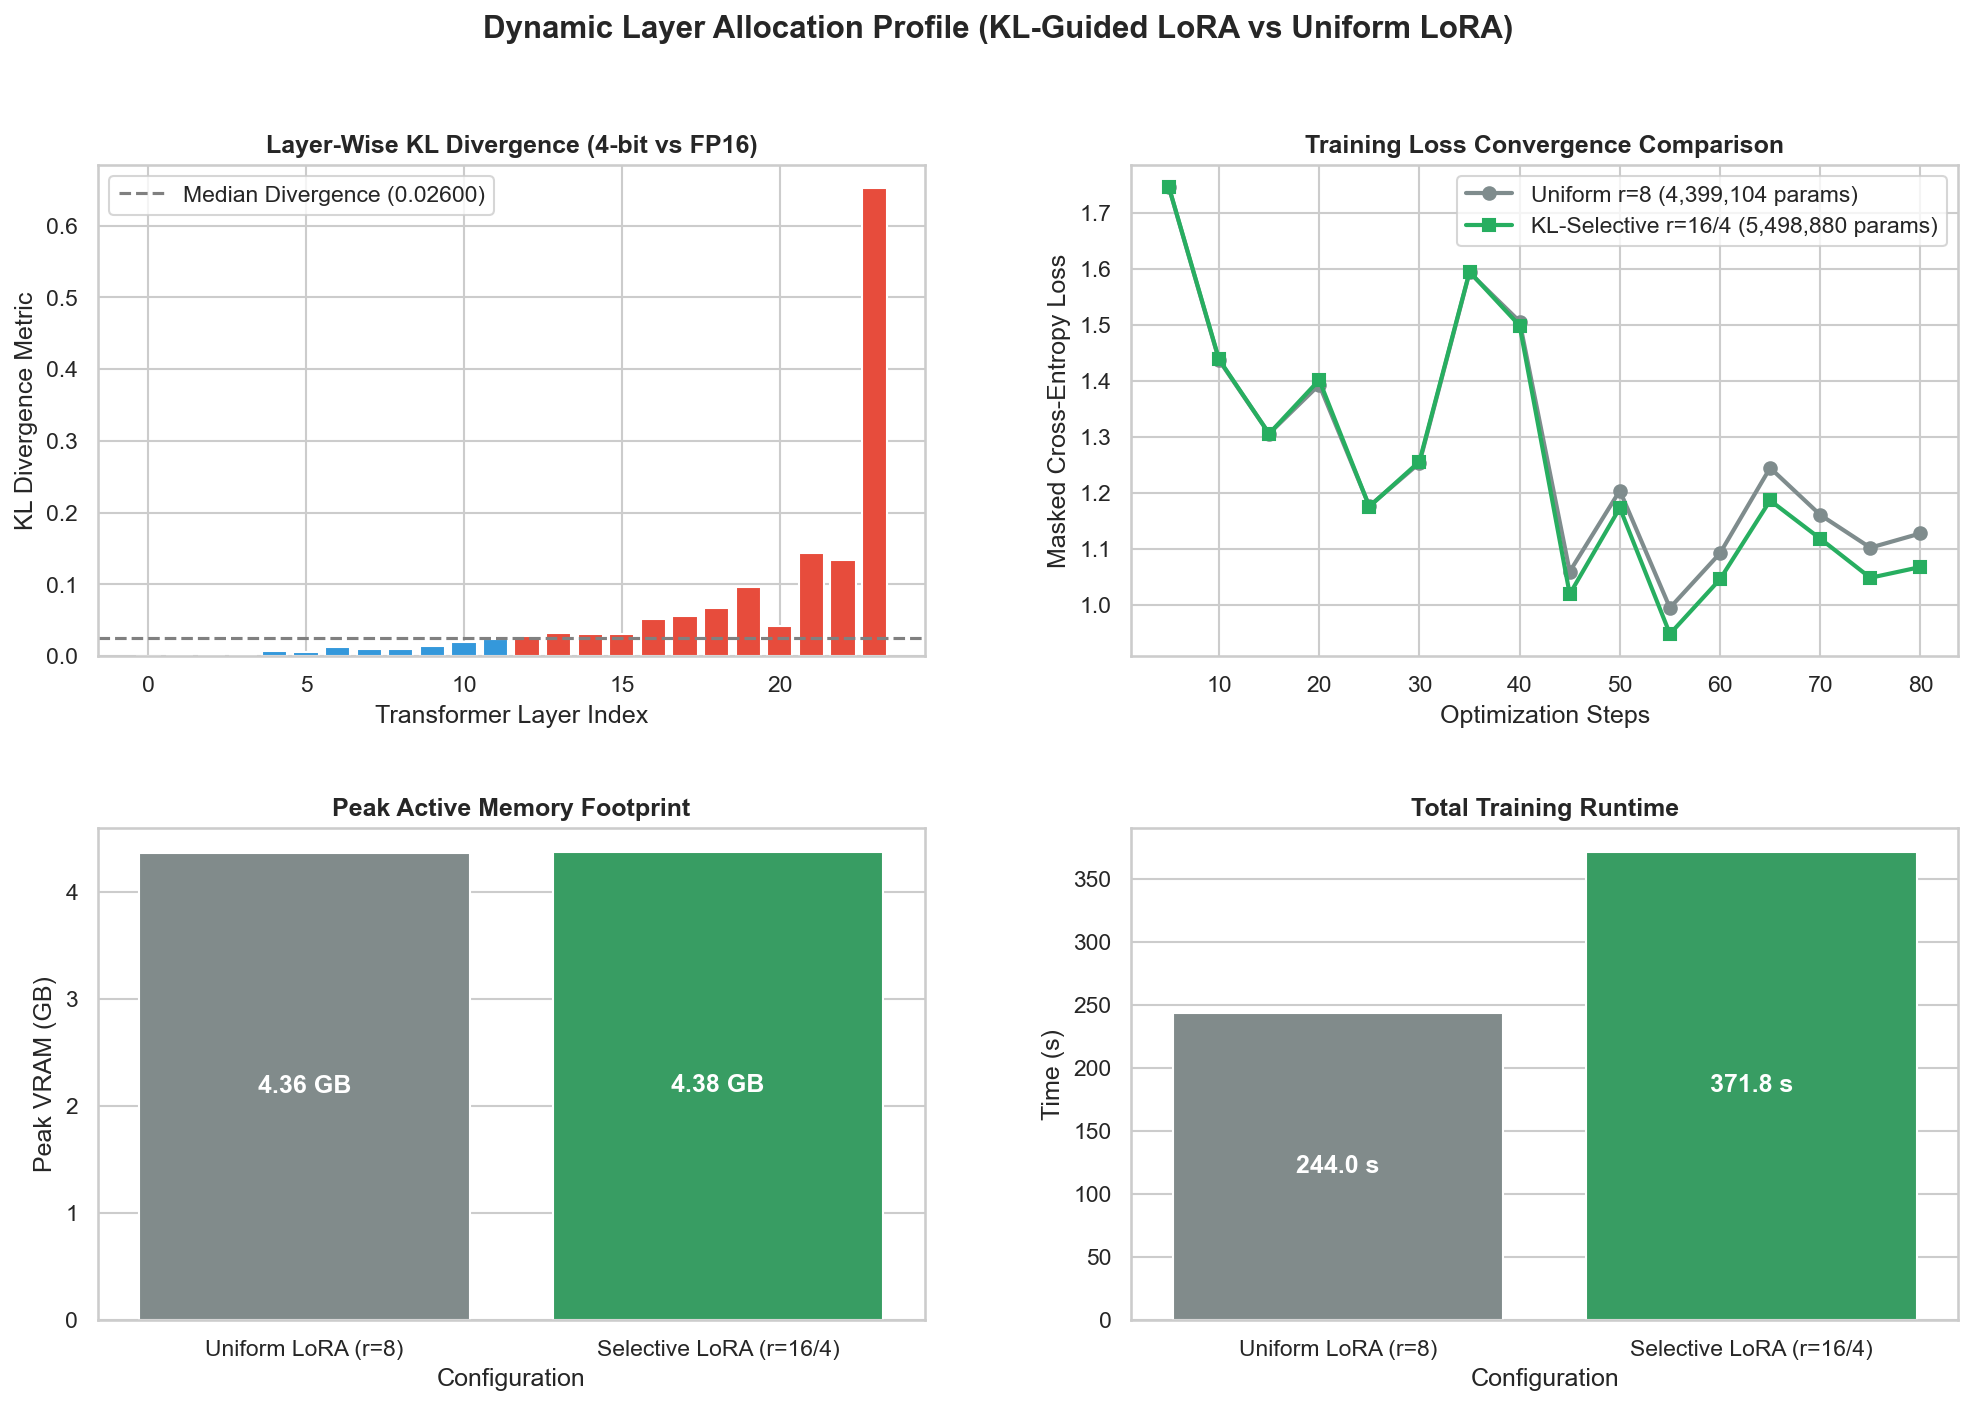


FINAL CONVERGENCE RESULT:
Uniform Baseline Final Loss:    1.1281
KL-Selective Final Loss:        1.0682
Saved publication-ready artifact: 'kl_guided_selective_lora.png'


In [12]:
# Cell 4: Visualization Dashboard
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=150)
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# 1. KL Divergence Heatmap Across Layers
axes[0, 0].bar(range(num_layers), kl_divergences, color=['#e74c3c' if i in critical_layers else '#3498db' for i in range(num_layers)])
axes[0, 0].axhline(median_kl, color='grey', linestyle='--', label=f'Median Divergence ({median_kl:.5f})')
axes[0, 0].set_title("Layer-Wise KL Divergence (4-bit vs FP16)", fontweight='bold')
axes[0, 0].set_xlabel("Transformer Layer Index")
axes[0, 0].set_ylabel("KL Divergence Metric")
axes[0, 0].legend()

# 2. Convergence Loss Trajectory
axes[0, 1].plot(cb_uniform.steps, cb_uniform.losses, marker='o', label=f'Uniform r=8 ({params_uniform:,} params)', color='#7f8c8d', linewidth=2)
axes[0, 1].plot(cb_selective.steps, cb_selective.losses, marker='s', label=f'KL-Selective r=16/4 ({params_selective:,} params)', color='#27ae60', linewidth=2)
axes[0, 1].set_title("Training Loss Convergence Comparison", fontweight='bold')
axes[0, 1].set_xlabel("Optimization Steps")
axes[0, 1].set_ylabel("Masked Cross-Entropy Loss")
axes[0, 1].legend()

# 3. Peak VRAM Comparison
df_vram = pd.DataFrame({
    'Configuration': ['Uniform LoRA (r=8)', 'Selective LoRA (r=16/4)'],
    'Peak VRAM (GB)': [vram_uniform, vram_selective]
})
sns.barplot(data=df_vram, x='Configuration', y='Peak VRAM (GB)', ax=axes[1, 0], palette=['#7f8c8d', '#27ae60'])
axes[1, 0].set_title("Peak Active Memory Footprint", fontweight='bold')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.2f} GB", 
                        (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold')

# 4. Latency / Run-Time Comparison
df_time = pd.DataFrame({
    'Configuration': ['Uniform LoRA (r=8)', 'Selective LoRA (r=16/4)'],
    'Time (s)': [time_uniform, time_selective]
})
sns.barplot(data=df_time, x='Configuration', y='Time (s)', ax=axes[1, 1], palette=['#7f8c8d', '#27ae60'])
axes[1, 1].set_title("Total Training Runtime", fontweight='bold')
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.1f} s", 
                        (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold')

plt.suptitle(f"Dynamic Layer Allocation Profile (KL-Guided LoRA vs Uniform LoRA)", fontsize=15, fontweight='heavy')
plt.savefig("kl_guided_selective_lora.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print(f"FINAL CONVERGENCE RESULT:")
print(f"Uniform Baseline Final Loss:    {cb_uniform.losses[-1]:.4f}")
print(f"KL-Selective Final Loss:        {cb_selective.losses[-1]:.4f}")
print("Saved publication-ready artifact: 'kl_guided_selective_lora.png'")
print("="*60)